In [1]:
# Import Libraries

import pandas as pd
import sqlite3 as sql
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from tensorflow.keras.layers import Dense
from sklearn.metrics import RocCurveDisplay
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

In [2]:
conn = sql.connect('ecommerce_hackathon.db')
conn

In [3]:
def sql_query(q):
    return pd.read_sql_query(q,conn)

# Task A: Database Inspection and Cleaning

In [4]:
cus_q = 'select * from customers'
sql_query(cus_q)

,customer_id,customer_name,age,gender,city,signup_date,membership_type,email,phone
0,1,Hassan Khan,20.0,Male,Karachi,2026-02-27,Standard,hassan.khan1@example.com,+92-3241-4744854
1,2,Maham Raza,33.0,Female,Rawalpindi,2025-10-17,Silver,maham.raza2@example.com,+92-3421-8078673
2,3,Ahmed Khan,25.0,Male,Karachi,2022-07-11,Standard,ahmed.khan3@example.com,+92-3139-9478454
3,4,Salman Khan,26.0,Male,Lahore,2025-02-23,Standard,salman.khan4@example.com,+92-3193-8038374
4,5,Noor Awan,27.0,Female,Lahore,2025-04-21,Standard,noor.awan5@example.com,+92-3210-3678638
...,...,...,...,...,...,...,...,...,...
7995,7996,Hassan Javed,44.0,Male,Lahore,2022-02-02,Standard,hassan.javed7996@example.com,+92-3060-7758111
7996,7997,Adeel Saeed,19.0,Male,Lahore,2022-01-24,Standard,adeel.saeed7997@example.com,+92-3141-8103048
7997,7998,Hussain Saeed,31.0,Male,Sargodha,2022-04-30,Standard,hussain.saeed7998@example.com,+92-3086-4725910
7998,7999,Anum Javed,34.0,Female,Sialkot,2025-11-20,Standard,anum.javed7999@example.com,+92-3492-7129798


In [5]:
customer_df = sql_query(cus_q)
customer_df

,customer_id,customer_name,age,gender,city,signup_date,membership_type,email,phone
0,1,Hassan Khan,20.0,Male,Karachi,2026-02-27,Standard,hassan.khan1@example.com,+92-3241-4744854
1,2,Maham Raza,33.0,Female,Rawalpindi,2025-10-17,Silver,maham.raza2@example.com,+92-3421-8078673
2,3,Ahmed Khan,25.0,Male,Karachi,2022-07-11,Standard,ahmed.khan3@example.com,+92-3139-9478454
3,4,Salman Khan,26.0,Male,Lahore,2025-02-23,Standard,salman.khan4@example.com,+92-3193-8038374
4,5,Noor Awan,27.0,Female,Lahore,2025-04-21,Standard,noor.awan5@example.com,+92-3210-3678638
...,...,...,...,...,...,...,...,...,...
7995,7996,Hassan Javed,44.0,Male,Lahore,2022-02-02,Standard,hassan.javed7996@example.com,+92-3060-7758111
7996,7997,Adeel Saeed,19.0,Male,Lahore,2022-01-24,Standard,adeel.saeed7997@example.com,+92-3141-8103048
7997,7998,Hussain Saeed,31.0,Male,Sargodha,2022-04-30,Standard,hussain.saeed7998@example.com,+92-3086-4725910
7998,7999,Anum Javed,34.0,Female,Sialkot,2025-11-20,Standard,anum.javed7999@example.com,+92-3492-7129798


### Show the shape and columns of each table.

# Customer Table

In [6]:
customer_df.shape

(8000, 9)

Table Contains 8000 rows and 9 columns

In [7]:
customer_df.columns

Index(['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date',
       'membership_type', 'email', 'phone'],
      dtype='object')

### Report the most important data quality issues you find.

In [8]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      8000 non-null   int64  
 1   customer_name    8000 non-null   object 
 2   age              7900 non-null   float64
 3   gender           8000 non-null   object 
 4   city             8000 non-null   object 
 5   signup_date      8000 non-null   object 
 6   membership_type  8000 non-null   object 
 7   email            8000 non-null   object 
 8   phone            8000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 562.6+ KB


### Issues with Data 
#### 1. age is float64; values may be negative/unrealistic
#### 2. signup_date is object

In [9]:
customer_df.describe()

,customer_id,age
count,8000.00000,7900.000000
mean,4000.50000,30.862405
std,2309.54541,8.392657
min,1.00000,18.000000
25%,2000.75000,24.000000
50%,4000.50000,31.000000
75%,6000.25000,37.000000
max,8000.00000,65.000000


In [10]:
customer_df.isnull().sum()

customer_id          0
customer_name        0
age                100
gender               0
city                 0
signup_date          0
membership_type      0
email                0
phone                0
dtype: int64

##### age has 7,900 non-null → 100 missing values

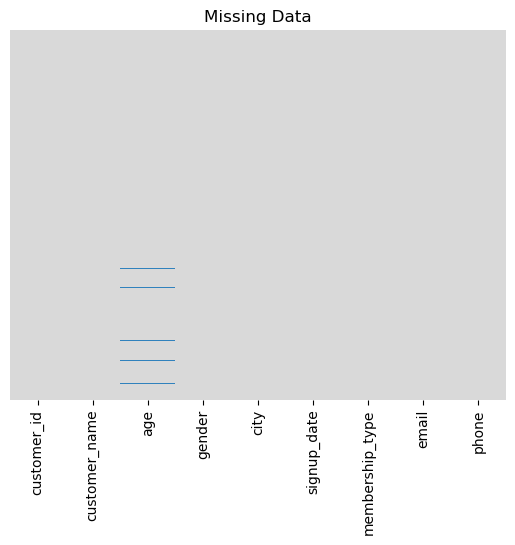

In [11]:
# Heatmap
sns.heatmap(customer_df.isnull(),yticklabels = False, cbar = False,cmap = 'tab20c_r')
plt.title('Missing Data')
plt.show()

C:\Users\Zubair Naseer\AppData\Local\Temp\ipykernel_22856\1104498667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'gender', y = 'age', data = customer_df, palette= 'GnBu_d').set_title('Age by Gender Class')


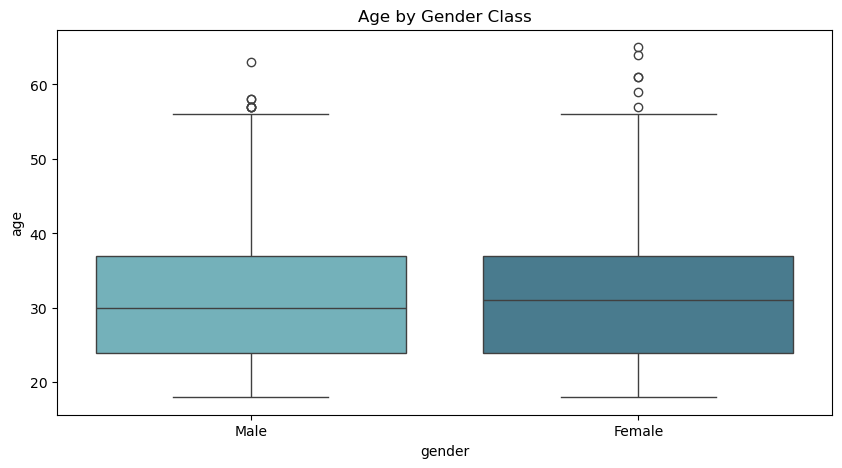

In [12]:
plt.figure(figsize = (10,5))
sns.boxplot(x = 'gender', y = 'age', data = customer_df, palette= 'GnBu_d').set_title('Age by Gender Class')
plt.show()

In [13]:
customer_df.groupby("gender")["age"].median()

gender
Female    31.0
Male      30.0
Name: age, dtype: float64

The age column contained missing values. The boxplot showed outliers in the age distribution, so median imputation was preferred over mean imputation because the median is less sensitive to extreme values. Since age distributions differed by gender, missing ages were imputed using the median age within each gender group rather than using a single median for the entire dataset.

In [14]:
# Imputation function
def impute_age(cols):
    age = cols[0]
    gender = cols[1]

    if pd.isnull(age):

        if gender == "Male":
            return 30

        elif gender == "Female":
            return 31
    else:
        return age


In [15]:
# Apply the function to the Age column
customer_df['age']=customer_df[['age','gender']].apply(impute_age, axis =1)

C:\Users\Zubair Naseer\AppData\Local\Temp\ipykernel_22856\4260513433.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = cols[0]
C:\Users\Zubair Naseer\AppData\Local\Temp\ipykernel_22856\4260513433.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gender = cols[1]


In [16]:
customer_df['age'].isnull().sum()

np.int64(0)

In [17]:
customer_df["age"] = customer_df["age"].astype("int64")

In [18]:
customer_df.dtypes

customer_id         int64
customer_name      object
age                 int64
gender             object
city               object
signup_date        object
membership_type    object
email              object
phone              object
dtype: object

In [20]:
#Convert signup date to datetime
customer_df["signup_date"] = pd.to_datetime(customer_df["signup_date"])

In [21]:
customer_df.dtypes

customer_id                 int64
customer_name              object
age                         int64
gender                     object
city                       object
signup_date        datetime64[ns]
membership_type            object
email                      object
phone                      object
dtype: object

In [22]:
# Duplicate rows
print("Duplicate rows:", customer_df.duplicated().sum())

Duplicate rows: 0


# Products Table

In [23]:
prod_q = 'select * from products'
prod_df = sql_query(prod_q)
prod_df

,product_id,product_name,category,brand,unit_price,stock_quantity
0,1,Readings Exam Guide Premium,Books & Stationery,Readings,566.45,103
1,2,Samsung Webcam Classic,Electronics,Samsung,10567.23,138
2,3,CA Sports Water Bottle Classic,Sports & Fitness,CA Sports,6665.04,63
3,4,LU Spice Mix Classic,Groceries,LU,516.49,113
4,5,L'Oreal Shampoo 2026,Beauty,L'Oreal,2581.35,107
...,...,...,...,...,...,...
995,996,Khaadi Jacket Standard,Fashion,Khaadi,779.25,126
996,997,L'Oreal Body Lotion 2026,Beauty,L'Oreal,405.86,122
997,998,Shan Detergent Mini,Groceries,Shan,362.19,136
998,999,Rivaj Sunscreen 2026,Beauty,Rivaj,1161.14,111


In [24]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   object 
 2   category        1000 non-null   object 
 3   brand           980 non-null    object 
 4   unit_price      1000 non-null   float64
 5   stock_quantity  1000 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 47.0+ KB


In [25]:
prod_df.describe()

,product_id,unit_price,stock_quantity
count,1000.000000,1000.000000,1000.000000
mean,500.500000,11071.693950,113.677000
std,288.819436,25155.633016,53.949172
min,1.000000,81.870000,11.000000
25%,250.750000,953.595000,72.000000
50%,500.500000,2748.185000,107.000000
75%,750.250000,8517.850000,145.000000
max,1000.000000,173670.200000,324.000000


### The maximum is much larger than the 75th percentile, so there may be high-price outliers.

In [26]:
print("Shape:", prod_df.shape)
print("Columns:", prod_df.columns.tolist())

Shape: (1000, 6)
Columns: ['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']


In [27]:
# Missing values
print(prod_df.isnull().sum())

product_id         0
product_name       0
category           0
brand             20
unit_price         0
stock_quantity     0
dtype: int64


### 20 Brands are Missing

In [28]:
prod_df['brand'].mode()

0    Khaadi
Name: brand, dtype: object

In [29]:
prod_df['brand']=prod_df['brand'].fillna('Unknown').str.strip()

In [30]:
prod_df['brand'] = prod_df['brand'].replace('Unknown', prod_df['brand'].mode()[0])

In [31]:
prod_df['brand'].isnull().sum()

np.int64(0)

In [32]:
# Duplicate rows
print("Duplicate rows:", prod_df.duplicated().sum())

Duplicate rows: 0


# Orders Table

In [33]:
ord_q = 'select * from orders'
ord_df = sql_query(ord_q)
ord_df

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned
0,1,2367,389,2026-04-30,1,398.27,0.108,Cash on Delivery,1.0,0
1,2,2038,927,2026-02-09,2,44488.20,0.084,Debit/Credit Card,1.0,0
2,3,6285,909,2026-03-30,1,4719.91,0.125,Cash on Delivery,1.0,0
3,4,3714,117,2026-03-24,1,2053.64,0.118,Easypaisa,4.0,0
4,5,3021,733,2024-12-13,1,31378.77,0.087,Debit/Credit Card,2.0,0
...,...,...,...,...,...,...,...,...,...,...
64995,64996,6245,849,2026-08-21,4,3576.73,0.054,Debit/Credit Card,2.0,0
64996,64997,3661,407,2026-08-27,1,3891.86,0.056,Cash on Delivery,2.0,0
64997,64998,4387,445,2026-08-28,2,5843.64,0.159,Debit/Credit Card,5.0,0
64998,64999,5684,102,2026-06-10,2,35106.59,0.067,Debit/Credit Card,3.0,0


In [34]:
ord_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        65000 non-null  int64  
 1   customer_id     65000 non-null  int64  
 2   product_id      65000 non-null  int64  
 3   order_date      65000 non-null  object 
 4   quantity        65000 non-null  int64  
 5   unit_price      65000 non-null  float64
 6   discount        65000 non-null  float64
 7   payment_method  64945 non-null  object 
 8   delivery_days   64960 non-null  float64
 9   returned        65000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 5.0+ MB


In [35]:
# Convert order_date to datetime
ord_df["order_date"] = pd.to_datetime(
    ord_df["order_date"],
    errors="coerce"
)

### Invalid date values were converted to NaT using pd.to_datetime(errors="coerce")

In [36]:
ord_df.isnull().sum()

order_id           0
customer_id        0
product_id         0
order_date        30
quantity           0
unit_price         0
discount           0
payment_method    55
delivery_days     40
returned           0
dtype: int64

In [37]:
ord_df['payment_method'] = ord_df['payment_method'].fillna(ord_df['payment_method'].mode()[0])

In [38]:
ord_df['payment_method'].isnull().sum()

np.int64(0)

In [39]:
ord_df['delivery_days']=ord_df['delivery_days'].fillna(ord_df['delivery_days'].median())

In [40]:
ord_df['delivery_days'].isnull().sum()

np.int64(0)

# Reviews Table

In [41]:
rev_q = 'select * from reviews'
rev_df = sql_query(rev_q)
rev_df

,review_id,customer_id,product_id,review_date,rating,review_text
0,1,7210,787,2026-07-28,4,"I would buy this again, item feels durable. Re..."
1,2,5566,765,2026-05-16,5,"Very satisfied, seller description was accurat..."
2,3,6106,743,2025-10-21,4,"Very satisfied, quality feels premium. Good va..."
3,4,2735,90,2026-03-25,4,"Product arrived in great condition, quality fe..."
4,5,2124,197,2026-02-23,4,"Good experience overall, packing was neat. Wil..."
...,...,...,...,...,...,...
25995,25996,2197,151,2024-05-31,4,"Good experience overall, customer support was ..."
25996,25997,5844,838,2026-08-31,5,"Quality is better than expected, price was rea..."
25997,25998,63,664,2024-11-12,4,"Good experience overall, quality feels premium..."
25998,25999,4723,278,2026-06-14,3,"It does the job, quality matches the price. No..."


In [42]:
rev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26000 entries, 0 to 25999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    26000 non-null  int64 
 1   customer_id  26000 non-null  int64 
 2   product_id   26000 non-null  int64 
 3   review_date  26000 non-null  object
 4   rating       26000 non-null  int64 
 5   review_text  25952 non-null  object
dtypes: int64(4), object(2)
memory usage: 1.2+ MB


In [43]:
# Convert order_date to datetime
rev_df["review_date"] = pd.to_datetime(
    rev_df["review_date"],
    errors="coerce"
)

In [44]:
rev_df["review_text"].isnull().sum()

np.int64(48)

In [45]:
rev_df["rating"].value_counts()

rating
4    10905
5     7583
3     5473
2     1437
1      577
6       14
0       11
Name: count, dtype: int64

In [46]:
# Remove rows with missing review date or review text
reviews_clean=rev_df.dropna(subset=['review_date','review_text']).copy()

### Keep only valid ratings from 1 to 5

In [47]:
reviews_clean=reviews_clean[reviews_clean.rating.between(1,5)].copy()

# Task B: SQL Business Analysis

### Calculate total net revenue.

In [48]:
# Remove orders with missing dates
orders_clean=ord_df.dropna(subset=['order_date']).copy()

In [49]:
#Remove invalid quantity and price
orders_clean=orders_clean[(orders_clean['quantity']>0)&(orders_clean['unit_price']>0)].copy()

In [50]:
# Calculate gross revenue
orders_clean['gross_revenue']=orders_clean.quantity*orders_clean.unit_price

In [51]:
# Calculate net revenue
orders_clean['net_revenue']=orders_clean.gross_revenue*(1-orders_clean.discount)*(1-orders_clean.returned)

In [52]:
orders_clean

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned,gross_revenue,net_revenue
0,1,2367,389,2026-04-30,1,398.27,0.108,Cash on Delivery,1.0,0,398.27,355.25684
1,2,2038,927,2026-02-09,2,44488.20,0.084,Debit/Credit Card,1.0,0,88976.40,81502.38240
2,3,6285,909,2026-03-30,1,4719.91,0.125,Cash on Delivery,1.0,0,4719.91,4129.92125
3,4,3714,117,2026-03-24,1,2053.64,0.118,Easypaisa,4.0,0,2053.64,1811.31048
4,5,3021,733,2024-12-13,1,31378.77,0.087,Debit/Credit Card,2.0,0,31378.77,28648.81701
...,...,...,...,...,...,...,...,...,...,...,...,...
64995,64996,6245,849,2026-08-21,4,3576.73,0.054,Debit/Credit Card,2.0,0,14306.92,13534.34632
64996,64997,3661,407,2026-08-27,1,3891.86,0.056,Cash on Delivery,2.0,0,3891.86,3673.91584
64997,64998,4387,445,2026-08-28,2,5843.64,0.159,Debit/Credit Card,5.0,0,11687.28,9829.00248
64998,64999,5684,102,2026-06-10,2,35106.59,0.067,Debit/Credit Card,3.0,0,70213.18,65508.89694


In [53]:
op=orders_clean.merge(prod_df[['product_id','category','product_name']],on='product_id',how='left').merge(customer_df[['customer_id','customer_name','city']],on='customer_id',how='left')

In [54]:
#Calculate total net revenue.
summary={
 'total_net_revenue':float(op.net_revenue.sum()),'total_orders':int(op.order_id.nunique()),'total_customers':int(op.customer_id.nunique()),
 'return_rate':float(op.returned.mean())}

In [55]:
print('summary',summary)

summary {'total_net_revenue': 865169922.03439, 'total_orders': 64890, 'total_customers': 7187, 'return_rate': 0.0669132377870242}


In [56]:
#Find the top 5 products by net revenue.

print('categories',op.groupby('category').net_revenue.sum().sort_values(ascending=False).head())

categories category
Electronics         5.894985e+08
Home & Kitchen      6.525803e+07
Fashion             5.462167e+07
Sports & Fitness    5.147245e+07
Beauty              4.351004e+07
Name: net_revenue, dtype: float64


In [57]:
print('cities',op.groupby('city').net_revenue.sum().sort_values(ascending=False).head())

cities city
Karachi       2.243050e+08
Lahore        1.551332e+08
Islamabad     8.290550e+07
Rawalpindi    7.276249e+07
Multan        5.781573e+07
Name: net_revenue, dtype: float64


## Monthly Revenue

In [58]:
monthly_revenue = (
    orders_clean
    .groupby(orders_clean['order_date'].dt.to_period('M'))['net_revenue']
    .sum()
    .reset_index()
)

print(monthly_revenue)

   order_date   net_revenue
0     2022-03  8.425491e+03
1     2022-04  8.074637e+04
2     2022-05  1.194615e+05
3     2022-06  2.039121e+05
4     2022-07  8.977847e+04
5     2022-08  6.989960e+05
6     2022-09  2.933531e+05
7     2022-10  3.617493e+05
8     2022-11  8.957299e+05
9     2022-12  5.583157e+05
10    2023-01  1.153622e+06
11    2023-02  1.095210e+06
12    2023-03  1.845093e+06
13    2023-04  1.253118e+06
14    2023-05  2.030306e+06
15    2023-06  2.419487e+06
16    2023-07  2.973026e+06
17    2023-08  3.114631e+06
18    2023-09  3.326551e+06
19    2023-10  3.178649e+06
20    2023-11  3.905641e+06
21    2023-12  4.265618e+06
22    2024-01  4.426147e+06
23    2024-02  5.397107e+06
24    2024-03  7.109369e+06
25    2024-04  7.539464e+06
26    2024-05  7.986382e+06
27    2024-06  7.235734e+06
28    2024-07  9.028116e+06
29    2024-08  1.051788e+07
30    2024-09  1.179886e+07
31    2024-10  1.147249e+07
32    2024-11  1.258674e+07
33    2024-12  1.579184e+07
34    2025-01  1.470

### Find the top 10 customers by total spending. Show customer name, city, number of orders and total spending.

In [59]:
query = """
SELECT
    c.customer_name,
    c.city,
    COUNT(DISTINCT o.order_id) AS number_of_orders,
    SUM(
        o.quantity * o.unit_price *
        (1 - o.discount) *
        (1 - o.returned)
    ) AS total_spending
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE
    date(o.order_date) IS NOT NULL
    AND o.quantity > 0
    AND o.unit_price > 0
GROUP BY
    o.customer_id,
    c.customer_name,
    c.city
ORDER BY
    total_spending DESC
LIMIT 10;
"""

top_customers = sql_query(query)

top_customers

,customer_name,city,number_of_orders,total_spending
0,Shahzaib Abbasi,Lahore,43,1.537801e+06
1,Zoya Awan,Lahore,55,1.515401e+06
2,Ahmed Qureshi,Lahore,27,1.452407e+06
3,Kiran Farooq,Karachi,61,1.353157e+06
4,Laiba Khan,Karachi,41,1.340945e+06
5,Adeel Khan,Karachi,42,1.333847e+06
6,Fahad Khan,Islamabad,53,1.252694e+06
7,Bilal Awan,Karachi,49,1.248564e+06
8,Imran Qureshi,Karachi,46,1.247070e+06
9,Danish Awan,Faisalabad,44,1.240877e+06


In [60]:
top_10_customers = (
    op.groupby(
        ['customer_id', 'customer_name', 'city']
    )
    .agg(
        number_of_orders=('order_id', 'nunique'),
        total_spending=('net_revenue', 'sum')
    )
    .reset_index()
    .sort_values(
        by='total_spending',
        ascending=False
    )
    .head(10)
)

top_10_customers

,customer_id,customer_name,city,number_of_orders,total_spending
536,595,Shahzaib Abbasi,Lahore,43,1.537801e+06
3524,3929,Zoya Awan,Lahore,55,1.515401e+06
6606,7343,Ahmed Qureshi,Lahore,27,1.452407e+06
5077,5646,Kiran Farooq,Karachi,61,1.353157e+06
3803,4242,Laiba Khan,Karachi,41,1.340945e+06
3394,3782,Adeel Khan,Karachi,42,1.333847e+06
422,470,Fahad Khan,Islamabad,53,1.252694e+06
5906,6561,Bilal Awan,Karachi,49,1.248564e+06
3934,4385,Imran Qureshi,Karachi,46,1.247070e+06
401,448,Danish Awan,Faisalabad,44,1.240877e+06


In [61]:
# Calculate category wise revenue, order count and quantity sold.
category_summary = (
    op.groupby('category')
    .agg(
        revenue=('net_revenue', 'sum'),
        order_count=('order_id', 'nunique'),
        quantity_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values(by='revenue', ascending=False)
)

category_summary

,category,revenue,order_count,quantity_sold
6,Electronics,5.894985e+08,11036,15467
13,Home & Kitchen,6.525803e+07,7527,10630
9,Fashion,5.462167e+07,12031,16852
15,Sports & Fitness,5.147245e+07,7063,9923
3,Beauty,4.351004e+07,11539,16034
1,Baby & Kids,2.698903e+07,3700,5261
17,electronics,1.134563e+07,182,253
11,Groceries,7.826997e+06,6052,8465
4,Books & Stationery,7.309200e+06,4922,6817
5,ELECTRONICS,3.038298e+06,276,380


# Task C: Exploratory Data Analysis

## Monthly Revenue Trend

In [62]:
monthly_revenue = (
    op.groupby(op['order_date'].dt.to_period('M'))['net_revenue']
    .sum()
    .reset_index()
)

# Convert Period to string for plotting
monthly_revenue['order_date'] = monthly_revenue['order_date'].astype(str)


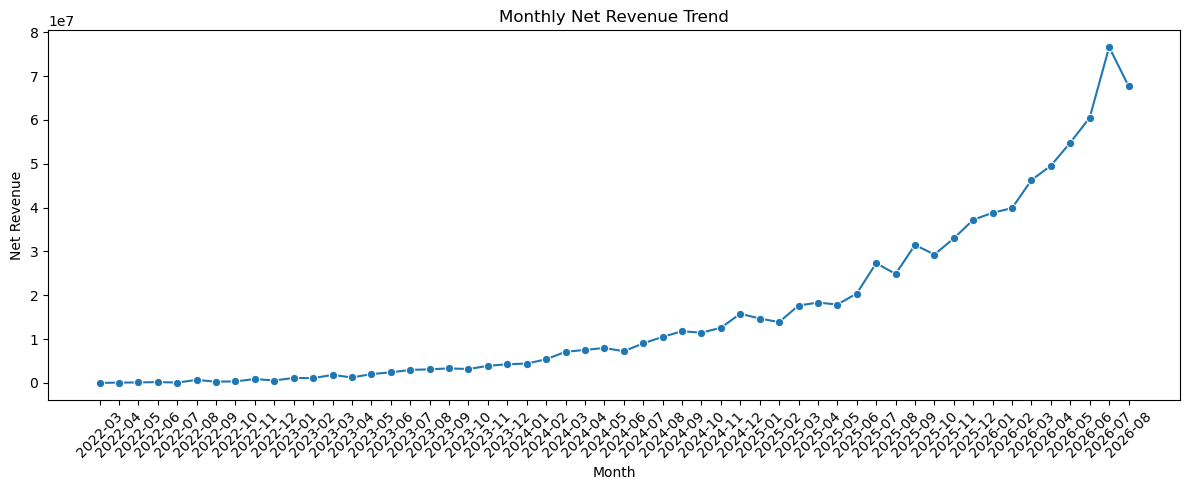

In [63]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x='order_date',
    y='net_revenue',
    marker='o'
)

plt.title('Monthly Net Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Net Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly revenue should be monitored for trend and seasonality. Changes in monthly revenue can reveal periods of stronger or weaker demand. If recurring peaks or declines emerge, the business can use this information for inventory planning, marketing campaigns, staffing, and cash-flow forecasting. However, the available time period should be considered before claiming a recurring seasonal pattern.

## Category-wise Revenue

In [64]:
category_revenue = (
    op.groupby('category')['net_revenue']
    .sum()
    .reset_index()
    .sort_values('net_revenue', ascending=False)
)

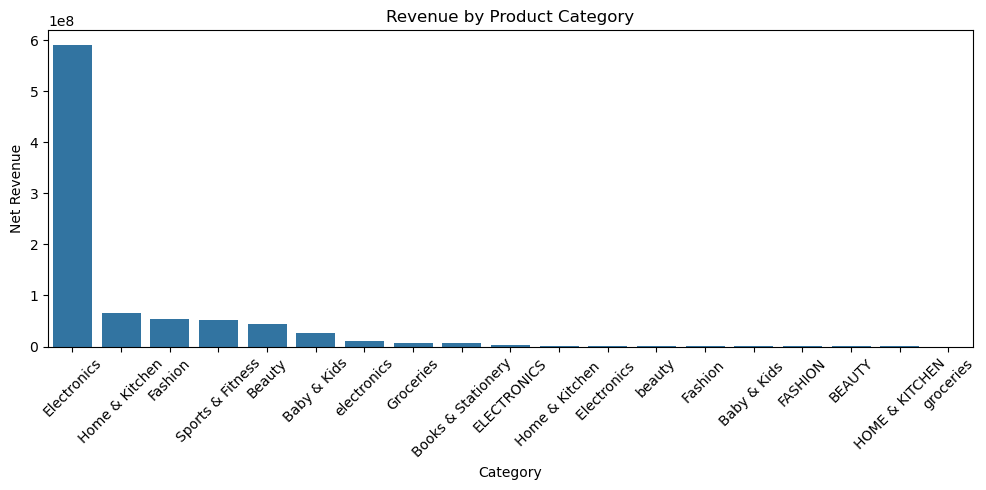

In [65]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_revenue,
    x='category',
    y='net_revenue'
)

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Net Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Electronics is the major revenue contributor. Electronics generates substantially more net revenue than the other product categories. This indicates that overall business performance is heavily dependent on electronics sales. Management should therefore prioritize stock availability, supplier reliability, pricing, and marketing for this category. At the same time, heavy dependence on one category creates concentration risk, so the company could investigate opportunities to increase revenue contribution from other categories.

## City-wise Revenue

In [66]:
city_revenue = (
    op.groupby('city')['net_revenue']
    .sum()
    .reset_index()
    .sort_values('net_revenue', ascending=False)
)

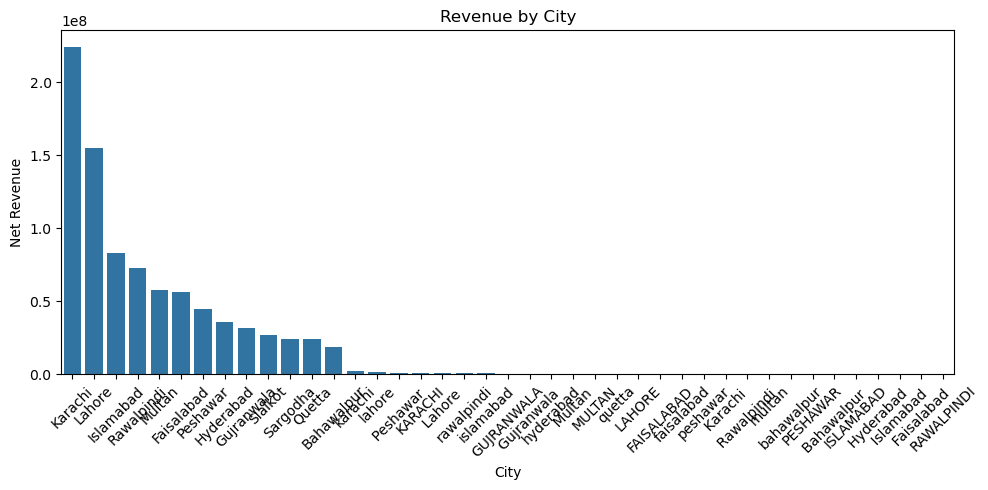

In [67]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=city_revenue,
    x='city',
    y='net_revenue'
)

plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Net Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Karachi is the strongest revenue-generating city. Karachi generates the highest net revenue among the customer cities in this dataset. This suggests that Karachi represents an important customer market for the company. The business could prioritize targeted marketing, inventory availability, and delivery capacity in this city while investigating whether lower-performing cities represent expansion opportunities rather than simply assuming demand is permanently lower.

## Return rate by product category

In [68]:
return_rate_category = (
    op.groupby('category')['returned']
    .mean()
    .mul(100)
    .reset_index(name='return_rate')
    .sort_values('return_rate', ascending=False)
)

return_rate_category

,category,return_rate
8,FASHION,17.391304
7,Electronics,11.904762
9,Fashion,11.254260
5,ELECTRONICS,9.782609
6,Electronics,7.973904
16,beauty,6.666667
13,Home & Kitchen,6.629467
2,Baby & Kids,6.521739
10,Fashion,6.194690
3,Beauty,5.823728


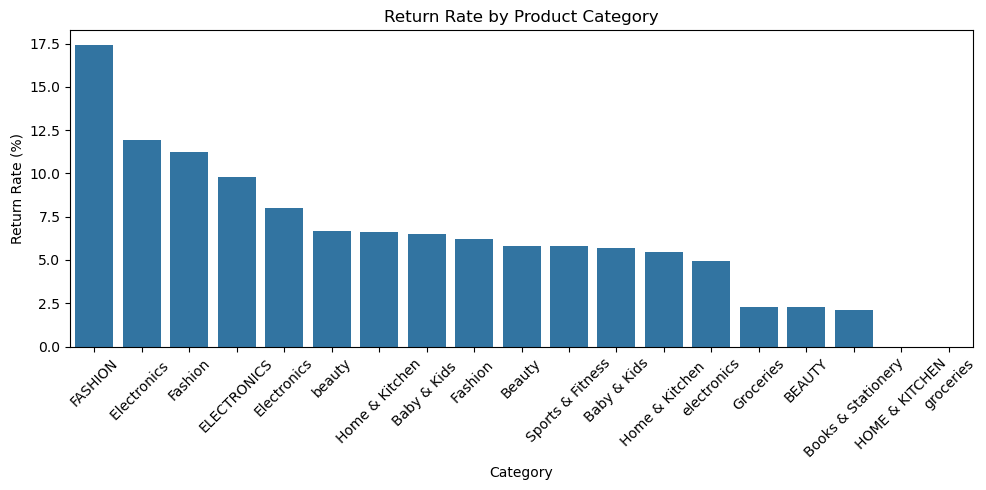

In [69]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=return_rate_category,
    x='category',
    y='return_rate'
)

plt.title('Return Rate by Product Category')
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Fashion has the highest observed return rate. A comparatively high return rate matters because returns reduce realized revenue and may increase logistics and handling costs. Management should investigate possible causes such as sizing issues, inaccurate product descriptions, product quality, or customer expectations. Reducing Fashion returns could improve profitability even without increasing gross sales.

# Task D Machine Learning: Customer Churn

In [70]:
import numpy as np

cutoff_date = pd.Timestamp('2026-05-31')
target_start = pd.Timestamp('2026-06-01')
target_end = pd.Timestamp('2026-08-31')

In [71]:
history = orders_clean[
    orders_clean['order_date'] <= cutoff_date
].copy()

In [72]:
target_orders = orders_clean[
    (orders_clean['order_date'] >= target_start) &
    (orders_clean['order_date'] <= target_end)
].copy()

In [73]:
customer_features = (
    history.groupby('customer_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_spending=('net_revenue', 'sum'),
        last_order_date=('order_date', 'max'),
        return_rate=('returned', 'mean'),
        avg_delivery_days=('delivery_days', 'mean')
    )
    .reset_index()
)

In [74]:
customer_features['avg_order_value'] = (
    customer_features['total_spending'] /
    customer_features['total_orders']
)

In [75]:
customer_features['days_since_last_order'] = (
    cutoff_date - customer_features['last_order_date']
).dt.days

In [76]:
customer_features = customer_features.merge(
    customer_df[
        ['customer_id', 'age', 'membership_type']
    ],
    on='customer_id',
    how='left'
)

In [77]:
active_customers = set(
    target_orders['customer_id'].unique()
)

In [78]:
customer_features['churn'] = (
    ~customer_features['customer_id'].isin(active_customers)
).astype(int)

In [79]:
customer_features.head()

,customer_id,total_orders,total_spending,last_order_date,return_rate,avg_delivery_days,avg_order_value,days_since_last_order,age,membership_type,churn
0,2,3,6229.49896,2026-05-28,0.0,4.666667,2076.499653,3,33,Silver,0
1,3,6,24102.46210,2026-02-13,0.0,3.166667,4017.077017,107,25,Standard,1
2,4,5,14400.81290,2026-05-18,0.0,3.000000,2880.162580,13,26,Standard,1
3,5,8,76312.80669,2026-05-12,0.0,3.500000,9539.100836,19,27,Standard,0
4,6,3,50020.16297,2025-03-17,0.0,3.000000,16673.387657,440,24,Standard,1


In [80]:
customer_features['churn'].value_counts()

churn
0    3329
1    3206
Name: count, dtype: int64

In [81]:
customer_features['churn'].value_counts(normalize=True) * 100

churn
0    50.941086
1    49.058914
Name: proportion, dtype: float64

In [82]:
customer_features.drop(
    columns=['last_order_date'],
    inplace=True
)

In [83]:
X = customer_features[
    [
        'total_orders',
        'total_spending',
        'avg_order_value',
        'days_since_last_order',
        'return_rate',
        'avg_delivery_days',
        'age',
        'membership_type'
    ]
]

y = customer_features['churn']

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [85]:
numeric_features = [
    'total_orders',
    'total_spending',
    'avg_order_value',
    'days_since_last_order',
    'return_rate',
    'avg_delivery_days',
    'age'
]

categorical_features = [
    'membership_type'
]

In [86]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [87]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

In [88]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [89]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [90]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [91]:
lr_pred = logistic_model.predict(X_test)

In [92]:
lr_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(1307,))

In [93]:
lr_prob = logistic_model.predict_proba(X_test)[:, 1]

In [94]:
lr_prob

array([0.57060931, 0.56493632, 0.13600697, ..., 0.21847038, 0.04503988,
       0.04757851], shape=(1307,))

In [95]:
rf_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

rf_preprocessor = ColumnTransformer([
    ('num', rf_numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

random_forest_model = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [96]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [97]:
rf_pred = random_forest_model.predict(X_test)

rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [98]:
print("LOGISTIC REGRESSION")

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, lr_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

LOGISTIC REGRESSION
Accuracy: 0.7161438408569243
Precision: 0.6670792079207921
Recall: 0.8408736349453978
F1 Score: 0.7439613526570048
ROC-AUC: 0.7868148960192641
Confusion Matrix:
[[397 269]
 [102 539]]


In [99]:
print("RANDOM FOREST")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

RANDOM FOREST
Accuracy: 0.7069625095638867
Precision: 0.6786703601108033
Recall: 0.7644305772230889
F1 Score: 0.719002201027146
ROC-AUC: 0.7646554510829082
Confusion Matrix:
[[434 232]
 [151 490]]


In [100]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.716,0.667,0.841,0.744,0.787
1,Random Forest,0.707,0.679,0.764,0.719,0.765


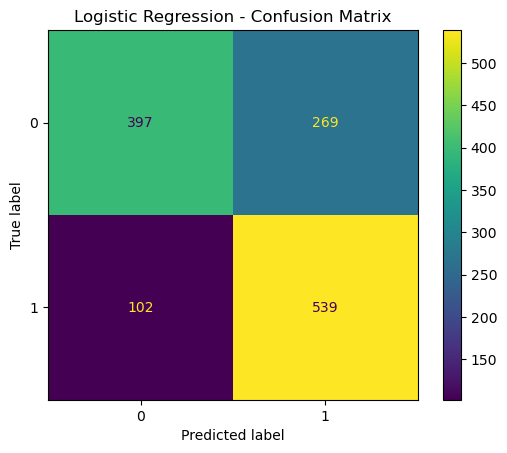

In [101]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.title('Logistic Regression - Confusion Matrix')
plt.show()

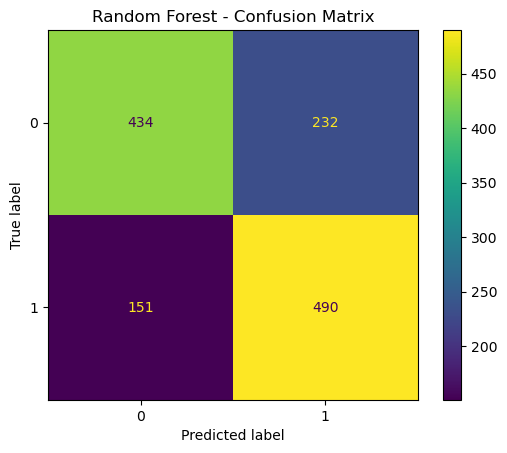

In [102]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title('Random Forest - Confusion Matrix')
plt.show()

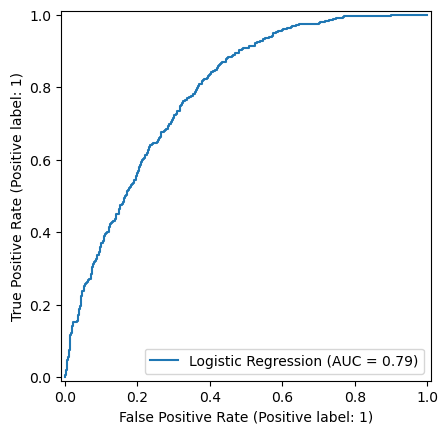

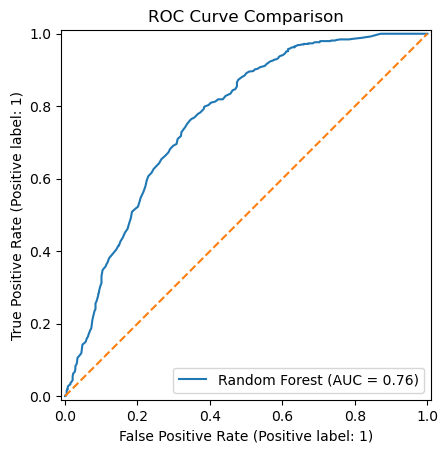

In [103]:
RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name='Logistic Regression'
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name='Random Forest'
)

plt.plot([0, 1], [0, 1], '--')
plt.title('ROC Curve Comparison')
plt.show()

`Model Selection:` Logistic Regression achieved approximately 71.5% accuracy, 66.1% precision, 86.0% recall, 74.8% F1-score and 78.7% ROC-AUC. Random Forest achieved similar accuracy of approximately 71.3% and slightly higher precision, but lower recall, F1-score and ROC-AUC. For this churn use case, Logistic Regression is selected because identifying customers who are actually likely to churn is important for retention campaigns. Its higher recall means it detects a larger proportion of actual churners, while its stronger F1-score provides a better balance between precision and recall. Its slightly higher ROC-AUC also indicates better overall discrimination between churners and non-churners.

In [104]:
import joblib

joblib.dump(
    logistic_model,
    'churn_model.pkl'
)

['churn_model.pkl']

# Task E: Deep Learning

In [105]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

nn_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [106]:
X_train_nn = nn_preprocessor.fit_transform(X_train)

X_test_nn = nn_preprocessor.transform(X_test)

In [107]:
print(X_train_nn.shape)
print(X_test_nn.shape)

(5228, 11)
(1307, 11)


In [108]:
tf.random.set_seed(42)

In [109]:
nn_model = Sequential([
    
    Dense(
        32,
        activation='relu',
        input_shape=(X_train_nn.shape[1],)
    ),
    
    Dense(
        16,
        activation='relu'
    ),
    
    Dense(
        1,
        activation='sigmoid'
    )
])

C:\Users\Zubair Naseer\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [110]:
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [111]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
history = nn_model.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6260 - loss: 0.6309 - val_accuracy: 0.7055 - val_loss: 0.5714
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6848 - loss: 0.5695 - val_accuracy: 0.7237 - val_loss: 0.5462
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6872 - loss: 0.5591 - val_accuracy: 0.7237 - val_loss: 0.5434
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6923 - loss: 0.5550 - val_accuracy: 0.7228 - val_loss: 0.5426
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6934 - loss: 0.5527 - val_accuracy: 0.7228 - val_loss: 0.5422
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6937 - loss: 0.5510 - val_accuracy: 0.7208 - val_loss: 0.5420
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6932 - loss: 0.5498 - val_accuracy: 0.7199 - val_loss: 0.5420
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6956 - loss: 0.5489 - val_accuracy: 0

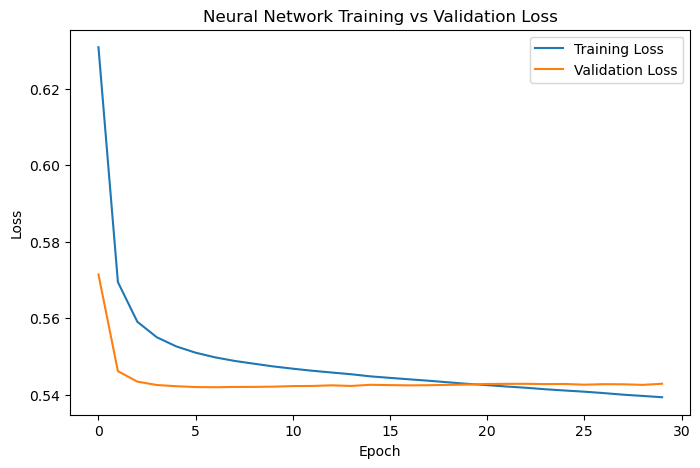

In [113]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural Network Training vs Validation Loss')
plt.legend()

plt.show()

In [114]:
nn_prob = nn_model.predict(X_test_nn).ravel()

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [115]:
nn_pred = (nn_prob >= 0.5).astype(int)

In [116]:
nn_accuracy = accuracy_score(
    y_test,
    nn_pred
)

nn_precision = precision_score(
    y_test,
    nn_pred
)

nn_recall = recall_score(
    y_test,
    nn_pred
)

nn_f1 = f1_score(
    y_test,
    nn_pred
)

nn_roc_auc = roc_auc_score(
    y_test,
    nn_prob
)

In [117]:
print("NEURAL NETWORK RESULTS")

print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1 Score:", nn_f1)
print("ROC-AUC:", nn_roc_auc)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        nn_pred
    )
)

NEURAL NETWORK RESULTS
Accuracy: 0.6985462892119357
Precision: 0.6526576019777504
Recall: 0.8237129485179407
F1 Score: 0.7282758620689656
ROC-AUC: 0.7721395342300179

Confusion Matrix:
[[385 281]
 [113 528]]


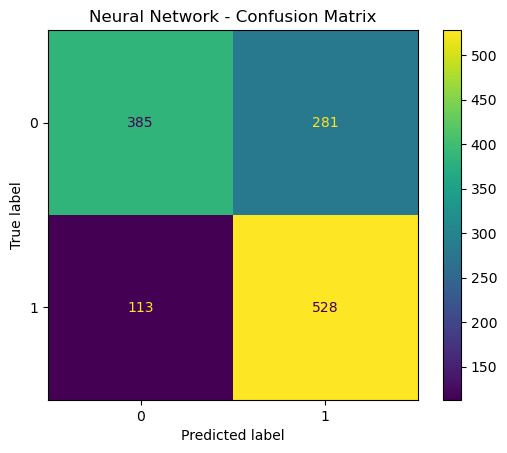

In [118]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nn_pred
)

plt.title('Neural Network - Confusion Matrix')
plt.show()

In [119]:
comparison = pd.DataFrame({
    
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Neural Network'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, nn_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, nn_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, nn_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, nn_pred)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, nn_prob)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.716,0.667,0.841,0.744,0.787
1,Random Forest,0.707,0.679,0.764,0.719,0.765
2,Neural Network,0.699,0.653,0.824,0.728,0.772


`Deep Learning Comparison:` The neural network achieved performance comparable to Logistic Regression and Random Forest, but it did not provide a meaningful improvement in F1-score or ROC-AUC. Since this is a relatively small structured/tabular customer dataset, the additional training complexity and preprocessing required by the neural network were not justified; Logistic Regression provides competitive performance while being simpler and easier to interpret.

# Task F: NLP Sentiment Analysis

In [120]:
reviews_clean = rev_df.dropna(
    subset=['review_date', 'review_text']
).copy()

reviews_clean = reviews_clean[
    reviews_clean['rating'].between(1, 5)
].copy()

reviews_clean['review_text'] = (
    reviews_clean['review_text']
    .str.strip()
)

reviews_clean = reviews_clean[
    reviews_clean['review_text'] != ''
].copy()

In [121]:
def create_sentiment(rating):
    
    if rating <= 2:
        return 'Negative'
    
    elif rating == 3:
        return 'Neutral'
    
    else:
        return 'Positive'

In [122]:
reviews_clean['sentiment'] = (
    reviews_clean['rating'].apply(create_sentiment)
)

In [123]:
reviews_clean[
    ['rating', 'review_text', 'sentiment']
].head(10)

,rating,review_text,sentiment
0,4,"I would buy this again, item feels durable. Re...",Positive
1,5,"Very satisfied, seller description was accurat...",Positive
2,4,"Very satisfied, quality feels premium. Good va...",Positive
3,4,"Product arrived in great condition, quality fe...",Positive
4,4,"Good experience overall, packing was neat. Wil...",Positive
5,1,"Very disappointed, item stopped working quickl...",Negative
6,3,"Decent but could be better, support response w...",Neutral
7,4,"Quality is better than expected, works exactly...",Positive
8,3,"Product is usable, some details were different...",Neutral
9,2,"Would not recommend, product had scratches. On...",Negative


In [124]:
reviews_clean['rating'].value_counts()

rating
4    10860
5     7550
3     5454
2     1430
1      575
Name: count, dtype: int64

In [125]:
reviews_clean['sentiment'].value_counts()

sentiment
Positive    18410
Neutral      5454
Negative     2005
Name: count, dtype: int64

In [126]:
X = reviews_clean['review_text']

In [127]:
y = reviews_clean['sentiment']

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [129]:
sentiment_model = Pipeline([
    
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2
    )),
    
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [130]:
sentiment_model.fit(
    X_train,
    y_train
)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [131]:
y_pred = sentiment_model.predict(X_test)

In [132]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

In [133]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [134]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       401
     Neutral       1.00      1.00      1.00      1091
    Positive       1.00      1.00      1.00      3682

    accuracy                           1.00      5174
   macro avg       1.00      1.00      1.00      5174
weighted avg       1.00      1.00      1.00      5174



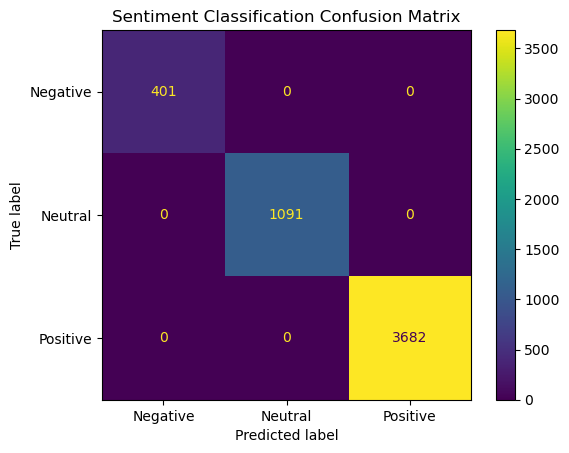

In [135]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
)

plt.title('Sentiment Classification Confusion Matrix')
plt.show()

In [136]:
test_reviews = [
    "The product is excellent and I love it",
    "The product is okay, nothing special",
    "Terrible quality and very disappointing"
]

predictions = sentiment_model.predict(
    test_reviews
)

for review, sentiment in zip(
    test_reviews,
    predictions
):
    print(review, "->", sentiment)

The product is excellent and I love it -> Positive
The product is okay, nothing special -> Neutral
Terrible quality and very disappointing -> Negative


In [137]:
joblib.dump(
    sentiment_model,
    'sentiment_model.pkl'
)

['sentiment_model.pkl']

`Limitation:` Sentiment labels are derived directly from customer ratings rather than manually annotated from the actual review text. A customer's written review may not always match their numerical rating, so the generated Negative, Neutral, and Positive labels may not perfectly represent the true sentiment expressed in the text.